In [6]:
import os, glob, time, h5py, warnings
import numpy as np
import scipy.sparse as sp
from libra_py import units, data_stat, influence_spectrum, data_conv
import matplotlib.pyplot as plt
from liblibra_core import *
from libra_py.workflows.nbra import step3
import libra_py.packages.cp2k.methods as CP2K_methods
from IPython.display import clear_output
import multiprocessing as mp
import util.libutil as comn
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.workflows.nbra.decoherence_times as decoherence_times
from liblibra_core import MATRIX
import matplotlib.cm as cm
from matplotlib.ticker import LogLocator, NullFormatter

## Active-Space Selection

> **Goal:** Select the frontier occupied orbitals and low-lying virtual orbitals that are most relevant to the electronic excitations.

Based on the **Kohn–Sham orbital-energy distribution**, a reasonable active space was selected to include the frontier occupied orbitals and the low-lying unoccupied orbitals that contribute most significantly to the excitation dynamics.

### Orbital range

- **Active-space orbitals:** `18–46`
- **HOMO:** orbital `38`
- **LUMO:** orbital `39`
- **Selected occupied orbitals:** `18–38`
- **Selected virtual orbitals:** `39–46`

$$
\boxed{\text{Occupied: } 18\text{--}38 \qquad \text{Virtual: } 39\text{--}46}
$$

This active space captures the dominant **occupied-to-virtual transitions** while excluding deeper occupied orbitals and higher-energy virtual orbitals that are energetically remote from the excitation window of interest.

Shape of energies array: (3005, 36)
blue: 18
red: 17
cyan: 1


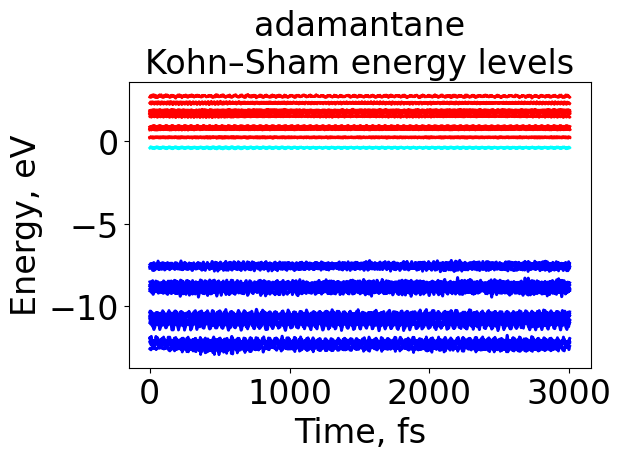

In [11]:
%matplotlib inline

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(3.21 * 2, 2.41 * 2))

energies = []

for step in range(5900, 8905):
    try:
        energy = np.diag(
            sp.load_npz(
                f'../step2_B3LYP/new_res/E_ks_{step}.npz'
            ).toarray()
        )
        energy_shape = energy.shape[0] // 2
        energies.append(energy[:energy_shape])

    except Exception as error:
        print(f"Error loading E_ks_{step}.npz: {error}")

if not energies:
    raise RuntimeError("No energy files were loaded.")

energies = np.asarray(energies) * units.au2ev
print(f"Shape of energies array: {energies.shape}")

color_counter = {
    'blue': 0,
    'red': 0,
    'cyan': 0,
    'gray': 0
}

for orbital in range(energies.shape[1]):

    if orbital == 18:
        color = 'cyan'
    elif 0 <= orbital < 18:
        color = 'blue'
    elif 19 <= orbital < 38:
        color = 'red'
    else:
        color = 'gray'

    color_counter[color] += 1

    ax.plot(
        energies[:, orbital],
        color=color,
        linewidth=2
    )

ax.set_xlabel('Time, fs')
ax.set_ylabel('Energy, eV')
ax.set_title('adamantane\nKohn–Sham energy levels')

for color, count in color_counter.items():
    if color != 'gray':
        print(f'{color}: {count}')

fig.tight_layout()

fig.savefig(
    'ks_0_methy.png',
    dpi=600,
    facecolor='white',
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

## Step 3: Data Generation

The Step 3 data were generated from the Step 2 outputs using the selected active space of orbitals `18–46`, where orbital `38` is the HOMO and orbital `39` is the LUMO.

In [3]:
params_active_space = {
    'lowest_orbital': 38-18, 'highest_orbital': 38+18, 'num_occ_orbitals': 18, 'num_unocc_orbitals': 18,
    'path_to_npz_files': os.getcwd()+'/../step2_B3LYP/res', 
    'logfile_directory': os.getcwd()+'/../step2_B3LYP/all_logfiles',
    'path_to_save_npz_files': os.getcwd()+'/../step2_B3LYP/new_res'
}
new_lowest_orbital, new_highest_orbital = step3.limit_active_space(params_active_space)

mkdir: cannot create directory ‘/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step3/../step2_B3LYP/new_res’: File exists


Restricting the active space for S..
Restricting the active space for St..
Restricting the active space for E..
Done with limiting the active space
Your new path_to_npz_files is now: /vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step3/../step2_B3LYP/new_res
Use the new lowest_orbital: 21 and highest_orbital: 56


In [4]:
pwd

'/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step3'

In [5]:
 os.getcwd()+'../step2_B3LYP/all_logfiles'

'/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step3../step2_B3LYP/all_logfiles'

In [6]:
params_mb_sd = {
          'lowest_orbital': new_lowest_orbital, 'highest_orbital': new_highest_orbital, 'num_occ_states': 18, 'num_unocc_states': 18,
          'isUKS': 0, 'number_of_states': 30, 'tolerance': 0.0, 'verbosity': 0, 'use_multiprocessing': True, 'nprocs': 12,
          'is_many_body': True, 'time_step': 1.0, 'es_software': 'cp2k',
          'path_to_npz_files': params_active_space['path_to_save_npz_files'],
           'logfile_directory': os.getcwd()+'/../step2_B3LYP/all_logfiles',
          'path_to_save_sd_Hvibs': os.getcwd()+'/../step33three_B3LYP',
          'outdir': os.getcwd()+'/../step33three_B3LYP', 'start_time': 5900, 'finish_time': 8905, 'sorting_type': 'energy',
         }

step3.run_step3_sd_nacs_libint(params_mb_sd)
clear_output()

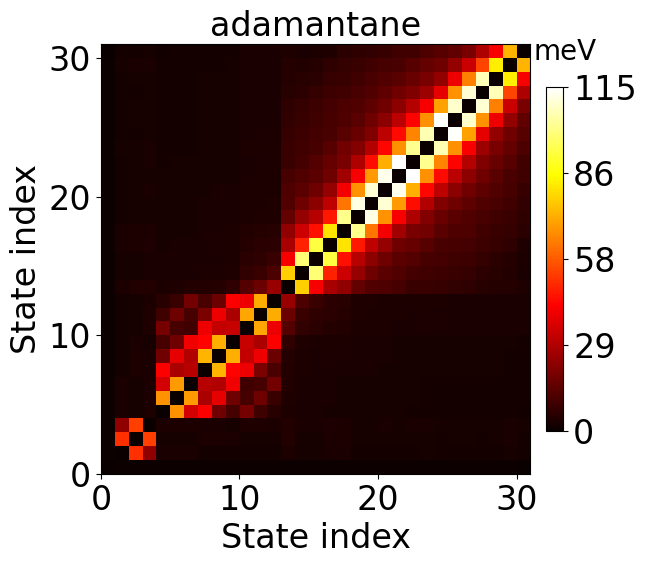

In [3]:
%matplotlib inline

plt.rcParams.update({
    'font.size': 24,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24
})

plt.figure(figsize=(7, 6))
basis = 'ci'
title = 'MB'

nac_files = glob.glob(F'/mnt/d/PCA_test/velocity/ad_paper/devel3_300K_11_23/step33three_B3LYP/Hvib_{basis}*im*')
for c2, nac_file in enumerate(nac_files):
    nac_mat = sp.load_npz(nac_file).todense().real
    if c2 == 0:
        nac_ave = np.zeros(nac_mat.shape)
    nac_ave += np.abs(nac_mat)
nac_ave *= 1000 * units.au2ev / c2  # unit meV

nstates = nac_ave.shape[0]
im = plt.imshow(np.flipud(nac_ave), cmap='hot', extent=(0, nstates, 0, nstates))

plt.xlabel('State index')
plt.ylabel('State index')


colorbar = plt.colorbar(im, shrink=0.8, aspect=20, pad=0.03)
colorbar.ax.tick_params(labelsize=24)


tick_values = np.linspace(np.min(nac_ave), np.max(nac_ave), 5)
colorbar.set_ticks(tick_values)
colorbar.set_ticklabels([f'{v:.0f}' for v in tick_values])


colorbar.ax.set_title('meV', fontsize=20, pad=20)
colorbar.ax.title.set_position((1.1, 1.02))  

plt.title(f'adamantane')
plt.tight_layout()


## Influence Spectrum

The influence spectrum was computed from the time-dependent energy gap between states `0` and `1`. The energy-gap trajectory was used to construct the autocorrelation function and the corresponding spectral density, $|J(\omega)|^2$, over the frequency range up to `4000 cm⁻¹`.

The contribution from low-frequency modes below `100 cm⁻¹` was quantified by integrating the spectrum in this region and comparing it with the total spectral intensity.

For additional details on the influence-spectrum analysis and its implementation, please refer to the [example analysis notebook](https://github.com/AkimovLab/Project_ML-BP/blob/main/4_analysis/pbe_plus_u/pristine/analysis.ipynb) and the JCP article, [*Excited-State Dynamics in Monolayer Black Phosphorus Revisited: Accounting for Many-Body Effects*](https://pubs-aip-org.gate.lib.buffalo.edu/aip/jcp/article/155/13/134106/1030258/Excited-state-dynamics-in-monolayer-black).


/tmp/ipykernel_222186/1629197941.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  low_integral = np.trapz(J2ij_np[low_mask], Wij_np[low_mask])
/tmp/ipykernel_222186/1629197941.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_integral = np.trapz(J2ij_np, Wij_np)


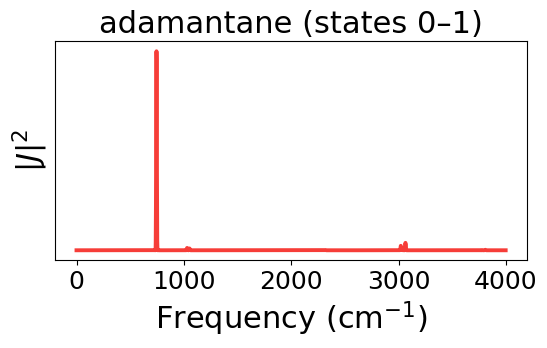

In [4]:
%matplotlib inline
# For computing influence spectra
params_inf_cpec = {
    "dt": 1.0,
    "wspan": 4000.0,
    "dw": 1.0,
    "do_output": False,
    "do_center": True,
    "acf_type": 1,
    "data_type": 0
}

# Selecting the two states
i = 0
j = 1


data_ij = []
for step in range(energies.shape[0]):
    x = MATRIX(1, 1)
    gap = abs(energies[step, j] - energies[step, i])  
    x.set(0, 0, gap)
    data_ij.append(x)


Tij, ACFij, uACFij, Wij, Jij, J2ij = influence_spectrum.recipe1(
    data_ij, params_inf_cpec
)


low_freq_cutoff = 100  # cm^-1

Wij_np = np.array(Wij)
J2ij_np = np.array(J2ij)

low_mask = Wij_np <= low_freq_cutoff
low_integral = np.trapz(J2ij_np[low_mask], Wij_np[low_mask])
total_integral = np.trapz(J2ij_np, Wij_np)
ratio = low_integral / total_integral

plt.figure(figsize=(6, 4))

plt.plot(
    Wij,
    J2ij,
    color="#F6322D",     
    linewidth=2.8,
    alpha=0.95
)

plt.xlabel('Frequency (cm$^{-1}$)', fontsize=22)
plt.ylabel(r'$|J|^2$', fontsize=22)
plt.yticks([])

plt.title(f'adamantane (states {i}–{j})', fontsize=22)
plt.tick_params(axis='both', labelsize=18)

plt.tight_layout()
plt.show()


## Time-Dependent Excitation Energies

The time-dependent configuration-interaction energies were extracted from the Step 3 vibronic Hamiltonian files and converted from atomic units to electronvolts using `units.au2ev`.

The excitation energy of each state was calculated relative to the ground state:

$$
\Delta E_i(t) = E_i(t) - E_0(t)
$$

The lowest 30 electronic states were plotted over the selected molecular-dynamics time interval. A blue-to-red color gradient was used to indicate increasing state index, allowing the temporal evolution and energetic distribution of the excited states to be visualized.

Checking file: /mnt/d/PCA_test/velocity/ad_paper/devel3_300K_11_23/step33three_B3LYP/Hvib_ci_5900_re.npz
Exists? True


/tmp/ipykernel_222186/1257499978.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("coolwarm", n_states_to_plot)   # low state blue → high state red


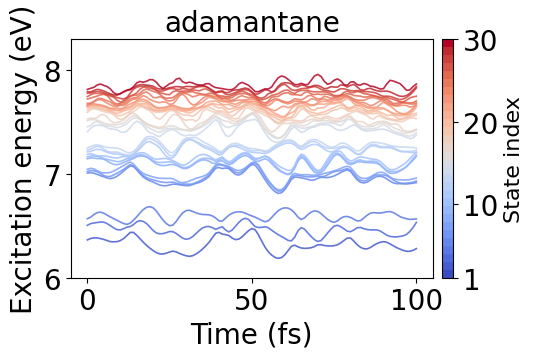

In [8]:
%matplotlib inline

params = {
    "path_to_energy_files": "/mnt/d/PCA_test/velocity/ad_paper/devel3_300K_11_23/step33three_B3LYP",
    "dt": 1.0,
    "prefix": "Hvib_ci_",   
    "suffix": "_re",
    "istep": 5900,
    "fstep": 6001
}


plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20
})

folder = params["path_to_energy_files"]


test_file = f"{folder}/Hvib_ci_{params['istep']}_re.npz"
print("Checking file:", test_file)
print("Exists?", os.path.exists(test_file))


md_time, energies = CP2K_methods.extract_energies_sparse(params)
energies = energies * units.au2ev


n_states_to_plot = min(30, energies.shape[1])

fig, ax = plt.subplots(figsize=(6, 4))

cmap   = cm.get_cmap("coolwarm", n_states_to_plot)   # low state blue → high state red
colors = [cmap(i / (n_states_to_plot - 1)) for i in range(n_states_to_plot)]

for i in range(n_states_to_plot):
    ax.plot(md_time,
            energies[:, i] - energies[:, 0],
            lw=1.2,
            color=colors[i],
            alpha=0.85)

# colorbar is state index
sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=1, vmax=n_states_to_plot))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("State index", fontsize=16)
cbar.set_ticks([1, 10, 20, 30])

ax.set_title("adamantane")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Excitation energy (eV)")
ax.set_ylim(6, 8.3)

fig.tight_layout()
fig.savefig("ci_energy_vs_time.png", dpi=300, bbox_inches="tight")

## Kohn–Sham Orbital-Energy Visualization

Based on the orbital-energy analysis described above, a short segment of the molecular-dynamics trajectory was selected for visualization. The Kohn–Sham orbital energies from steps `5900–5940` were extracted from the Step 2 output files.

Shape of energies array: (41, 36)


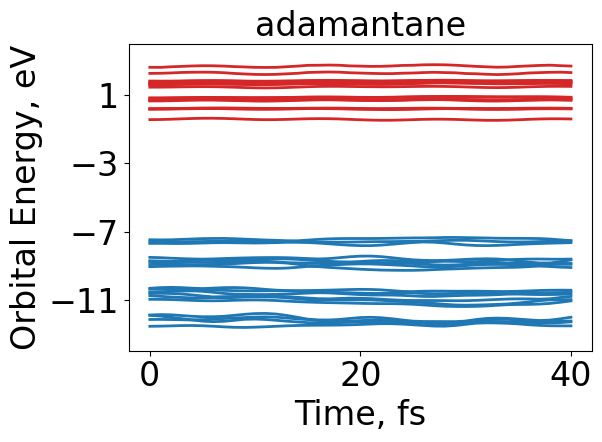

#1F77B4: 18
#D62728: 18


In [9]:
plt.rcParams.update({
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
})

plt.figure(figsize=(3.21*2, 2.41*2))

energies = []
for i in range(5900, 5941):
    try:
        energy = np.diag(
            sp.load_npz(f'../step2_B3LYP/new_res/E_ks_{i}.npz').toarray()
        )
        energy_shape = int(energy.shape[0] / 2)
        energies.append(energy[:energy_shape])
    except Exception as e:
        print(f"Error loading file E_ks_{i}.npz: {e}")

energies = np.array(energies) * units.au2ev
print(f"Shape of energies array: {energies.shape}")

color_counter = {
    '#1F77B4': 0,
    '#D62728': 0,
}

for i in range(energies.shape[1]):
    if 18 <= i <= 46:
        color = '#D62728'
        color_counter[color] += 1
    elif 0 <= i <= 17:
        color = '#1F77B4'
        color_counter[color] += 1
    else:
        color = 'gray'

    plt.plot(
        energies[:, i],
        color=color,
        linewidth=2,
        linestyle='-'
    )

plt.xlabel('Time, fs')
plt.ylabel('Orbital Energy, eV')
plt.title('adamantane')

plt.ylim(-14, 4)          
plt.yticks(np.arange(-11, 4, 4))    

plt.tick_params(axis='both', which='major')

plt.tight_layout()
plt.savefig('ks_0_methy111.png', dpi=600, facecolor='white')
plt.show()

for color, count in color_counter.items():
    print(f'{color}: {count}')

## S$_1$–S$_0$ Energy-Gap Distribution

The diagonal energies of the ground and first excited states were extracted from the Step 3 vibronic Hamiltonian files over the selected trajectory interval from step `5900` to `8900`.

The S$_1$–S$_0$ energy gap was converted from atomic units to electronvolts using `units.au2ev`. Its probability-density distribution was then evaluated with a bin width of `0.02 eV` and normalized so that the total integrated area equals one.

The resulting distribution was plotted on a logarithmic scale, and the most probable energy gap was identified from the maximum of the probability density.

/tmp/ipykernel_222186/3210875873.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(dens, bin_supp)


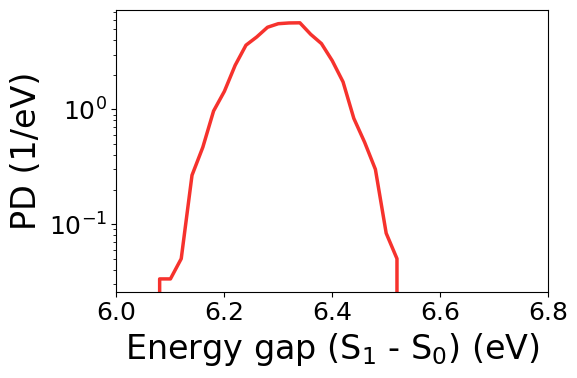


========== PD Peak Summary ==========
Adamantane: E_peak = 6.340 eV, PD_peak = 5.665e+00 1/eV


In [13]:
%matplotlib inline

# ============================================================
# Adamantane configuration
# ============================================================

base_dir = "/mnt/d/PCA_test/velocity/ad_paper/devel3_300K_11_23/step33three_B3LYP"
STEP_MIN = 5900
STEP_MAX = 8900
FIXED_COLOR = "#F6322D"

# ============================================================
# Read S1 diagonal energies
# ============================================================

energies_S1 = []

energy_files = glob.glob(os.path.join(base_dir, "Hvib_ci*re*"))

if len(energy_files) == 0:
    raise RuntimeError(f"No Hvib_ci*re* files found in {base_dir}")

for ene_file in energy_files:

    fname = os.path.basename(ene_file)

    try:
        step = int(fname.split("_")[2])
    except Exception:
        continue

    if not (STEP_MIN <= step <= STEP_MAX):
        continue

    hvib = sp.load_npz(ene_file).todense().real

    if hvib.shape[0] < 2:
        continue

    # S1 diagonal energy: Hartree → eV
    E1 = hvib[1, 1] * units.au2ev

    x1 = MATRIX(1, 1)
    x1.set(0, 0, E1)
    energies_S1.append(x1)

if len(energies_S1) == 0:
    raise RuntimeError("No valid S1 energy data were found.")

# ============================================================
# Probability-density distribution
# ============================================================

bin_supp, dens, cum = data_stat.cmat_distrib(
    energies_S1,
    0,
    0,
    0,
    -1.0,
    8.0,
    0.02
)

bin_supp = np.array(bin_supp)
dens = np.array(dens)

# Normalize the probability density
area = np.trapz(dens, bin_supp)

if area > 1e-15:
    dens /= area

# ============================================================
# Find the peak
# ============================================================

idx_peak = np.argmax(dens)
E_peak = bin_supp[idx_peak]
PD_peak = dens[idx_peak]

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    bin_supp,
    dens,
    linewidth=2.5,
    color=FIXED_COLOR,
    label="Adamantane"
)

plt.xscale("linear")
plt.yscale("log")
plt.xlim([6.0, 6.8])

plt.xlabel(r'Energy gap (S$_1$ - S$_0$) (eV)', fontsize=24)
plt.ylabel("PD (1/eV)", fontsize=24)
plt.tick_params(axis="both", which="major", labelsize=18)

plt.tight_layout()

plt.savefig(
    "Energy_S1_PD_adamantane.png",
    dpi=600,
    facecolor="white",
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# Print peak result
# ============================================================

print("\n========== PD Peak Summary ==========")
print(
    f"Adamantane: "
    f"E_peak = {E_peak:.3f} eV, "
    f"PD_peak = {PD_peak:.3e} 1/eV"
)

## NAC Distribution

The nonadiabatic coupling between the ground and first excited states, $|NAC(S_0,S_1)|$, was extracted from the imaginary part of the Step 3 vibronic Hamiltonian over the selected trajectory interval from step `5900` to `8900`.

The coupling values were converted from atomic units to meV using `units.au2ev`. Their probability-density distribution was then calculated and normalized so that the total integrated area equals one.

The resulting NAC distribution was plotted on logarithmic scales to better visualize the low-probability region and the spread of coupling values.

/tmp/ipykernel_222186/242643628.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(dens, bin_supp)


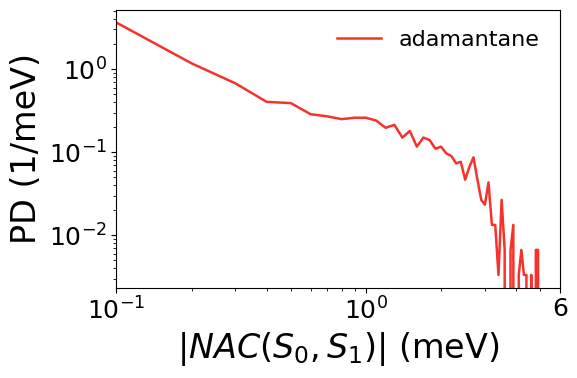

In [15]:
%matplotlib inline

# ============================================================
# Adamantane configuration
# ============================================================

base_dir = "/mnt/d/PCA_test/velocity/ad_paper/devel3_300K_11_23/step33three_B3LYP"
STEP_MIN = 5900
STEP_MAX = 8900
FIXED_COLOR = "#F6322D"
LABEL = "adamantane"

# ============================================================
# Read NAC(S0,S1) data
# ============================================================

nac = []

# Match NAC imag files
nac_files = glob.glob(os.path.join(base_dir, "Hvib_ci*im*"))

if len(nac_files) == 0:
    raise RuntimeError(f"No Hvib_ci*im* files found in {base_dir}")

for nac_file in nac_files:

    fname = os.path.basename(nac_file)

    # Parse step from filename
    try:
        step = int(fname.split("_")[2])
    except Exception:
        print(f"[Warning] Unexpected filename: {fname}")
        continue

    if not (STEP_MIN <= step <= STEP_MAX):
        continue

    # Read imaginary part of Hvib
    hvib = sp.load_npz(nac_file).todense().real
    nst = hvib.shape[0]

    if nst < 2:
        print(f"[Warning] NAC matrix too small in {nac_file}")
        continue

    # |NAC(S0,S1)| -> meV
    val = abs(hvib[0, 1]) * 1000.0 * units.au2ev
    x = MATRIX(1, 1)
    x.set(0, 0, val)
    nac.append(x)

if len(nac) == 0:
    raise RuntimeError("No NAC(S0,S1) data found for adamantane.")

# ============================================================
# Probability-density distribution
# ============================================================

bin_supp, dens, cum = data_stat.cmat_distrib(
    nac, 0, 0, 0, 0, 30, 0.1
)

bin_supp = np.array(bin_supp)
dens = np.array(dens)

# Normalize
area = np.trapz(dens, bin_supp)
if area > 1e-15:
    dens /= area

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    bin_supp,
    dens,
    label=LABEL,
    linewidth=1.8,
    color=FIXED_COLOR
)

plt.xscale("log")
plt.yscale("log")
plt.xlim([1e-1, 6])

ax = plt.gca()

# major / minor ticks
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=10))
ax.xaxis.set_minor_locator(
    LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=10)
)
ax.xaxis.set_minor_formatter(NullFormatter())

# manual ticks
ax.set_xticks([1e-1, 1e0, 6])
ax.set_xticklabels([r"$10^{-1}$", r"$10^{0}$", "6"])

plt.xlabel(r"$|NAC(S_0,S_1)|$ (meV)", fontsize=24)
plt.ylabel("PD (1/meV)", fontsize=24)
plt.tick_params(axis="both", which="major", labelsize=18)

plt.legend(
    fontsize=16,
    frameon=False,
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    "NAC_S0S1_PD_adamantane.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()